### THIS NOTEBOOK PERFORMS REGRESSION ANALYSIS OF PTEs, pH, AND ORGANIC MATTER VARIATION WITH DISTANCE FROM THE EMISSION SOURCE

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
# LOAD THE DATASET
Topdf = pd.read_excel('TopSoil_Compiled EDXFR Results_Orginal.xlsx')
Topdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Lab. No           63 non-null     int64  
 1   Field No          63 non-null     object 
 2   Horizon Cm        63 non-null     object 
 3   Lab Sample #      63 non-null     int64  
 4   Latitude          63 non-null     float64
 5   Longitude         63 non-null     float64
 6   Elev(m)           63 non-null     int64  
 7   dES(km)           63 non-null     float64
 8   dES(m)            63 non-null     float64
 9   dRD(m)            63 non-null     float64
 10  0.01M CaCl2 (pH)  63 non-null     float64
 11  Fe (mg/kg)        63 non-null     float64
 12  Cu (mg/kg)        63 non-null     float64
 13  Zn (mg/kg)        63 non-null     float64
 14  Cd (mg/kg)        63 non-null     float64
 15  As (mg/kg)        63 non-null     int64  
 16  Pb (mg/kg)        63 non-null     float64
 17 

In [3]:
# REMOVE COLUMNS THAT ARE NOT NEEDED
Topdf = Topdf.drop(columns=['Lab. No', 'Field No', 'Horizon Cm', 'Lab Sample #'])

In [4]:
# RENAME COLUMNS FOR EASY REFERENCE
Topdf = Topdf.rename(columns={'0.01M CaCl2 (pH)': 'pH',
                             'Cd (mg/kg)': 'Cd',
                             'Pb (mg/kg)': 'Pb',
                             'Zn (mg/kg)': 'Zn',
                             'Cu (mg/kg)': 'Cu',
                             'Fe (mg/kg)': 'Fe',
                             'dES(m)': 'distance'})
Topdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    63 non-null     float64
 1   Longitude   63 non-null     float64
 2   Elev(m)     63 non-null     int64  
 3   dES(km)     63 non-null     float64
 4   distance    63 non-null     float64
 5   dRD(m)      63 non-null     float64
 6   pH          63 non-null     float64
 7   Fe          63 non-null     float64
 8   Cu          63 non-null     float64
 9   Zn          63 non-null     float64
 10  Cd          63 non-null     float64
 11  As (mg/kg)  63 non-null     int64  
 12  Pb          63 non-null     float64
 13  Hg (mg/kg)  63 non-null     int64  
 14  OM          63 non-null     float64
dtypes: float64(12), int64(3)
memory usage: 7.5 KB


### 1. REGRESSION ANALYSIS OF PTEs CONCENTRATION VARIATION WITH DISTANCE FROM THE EMISSION SOURCE

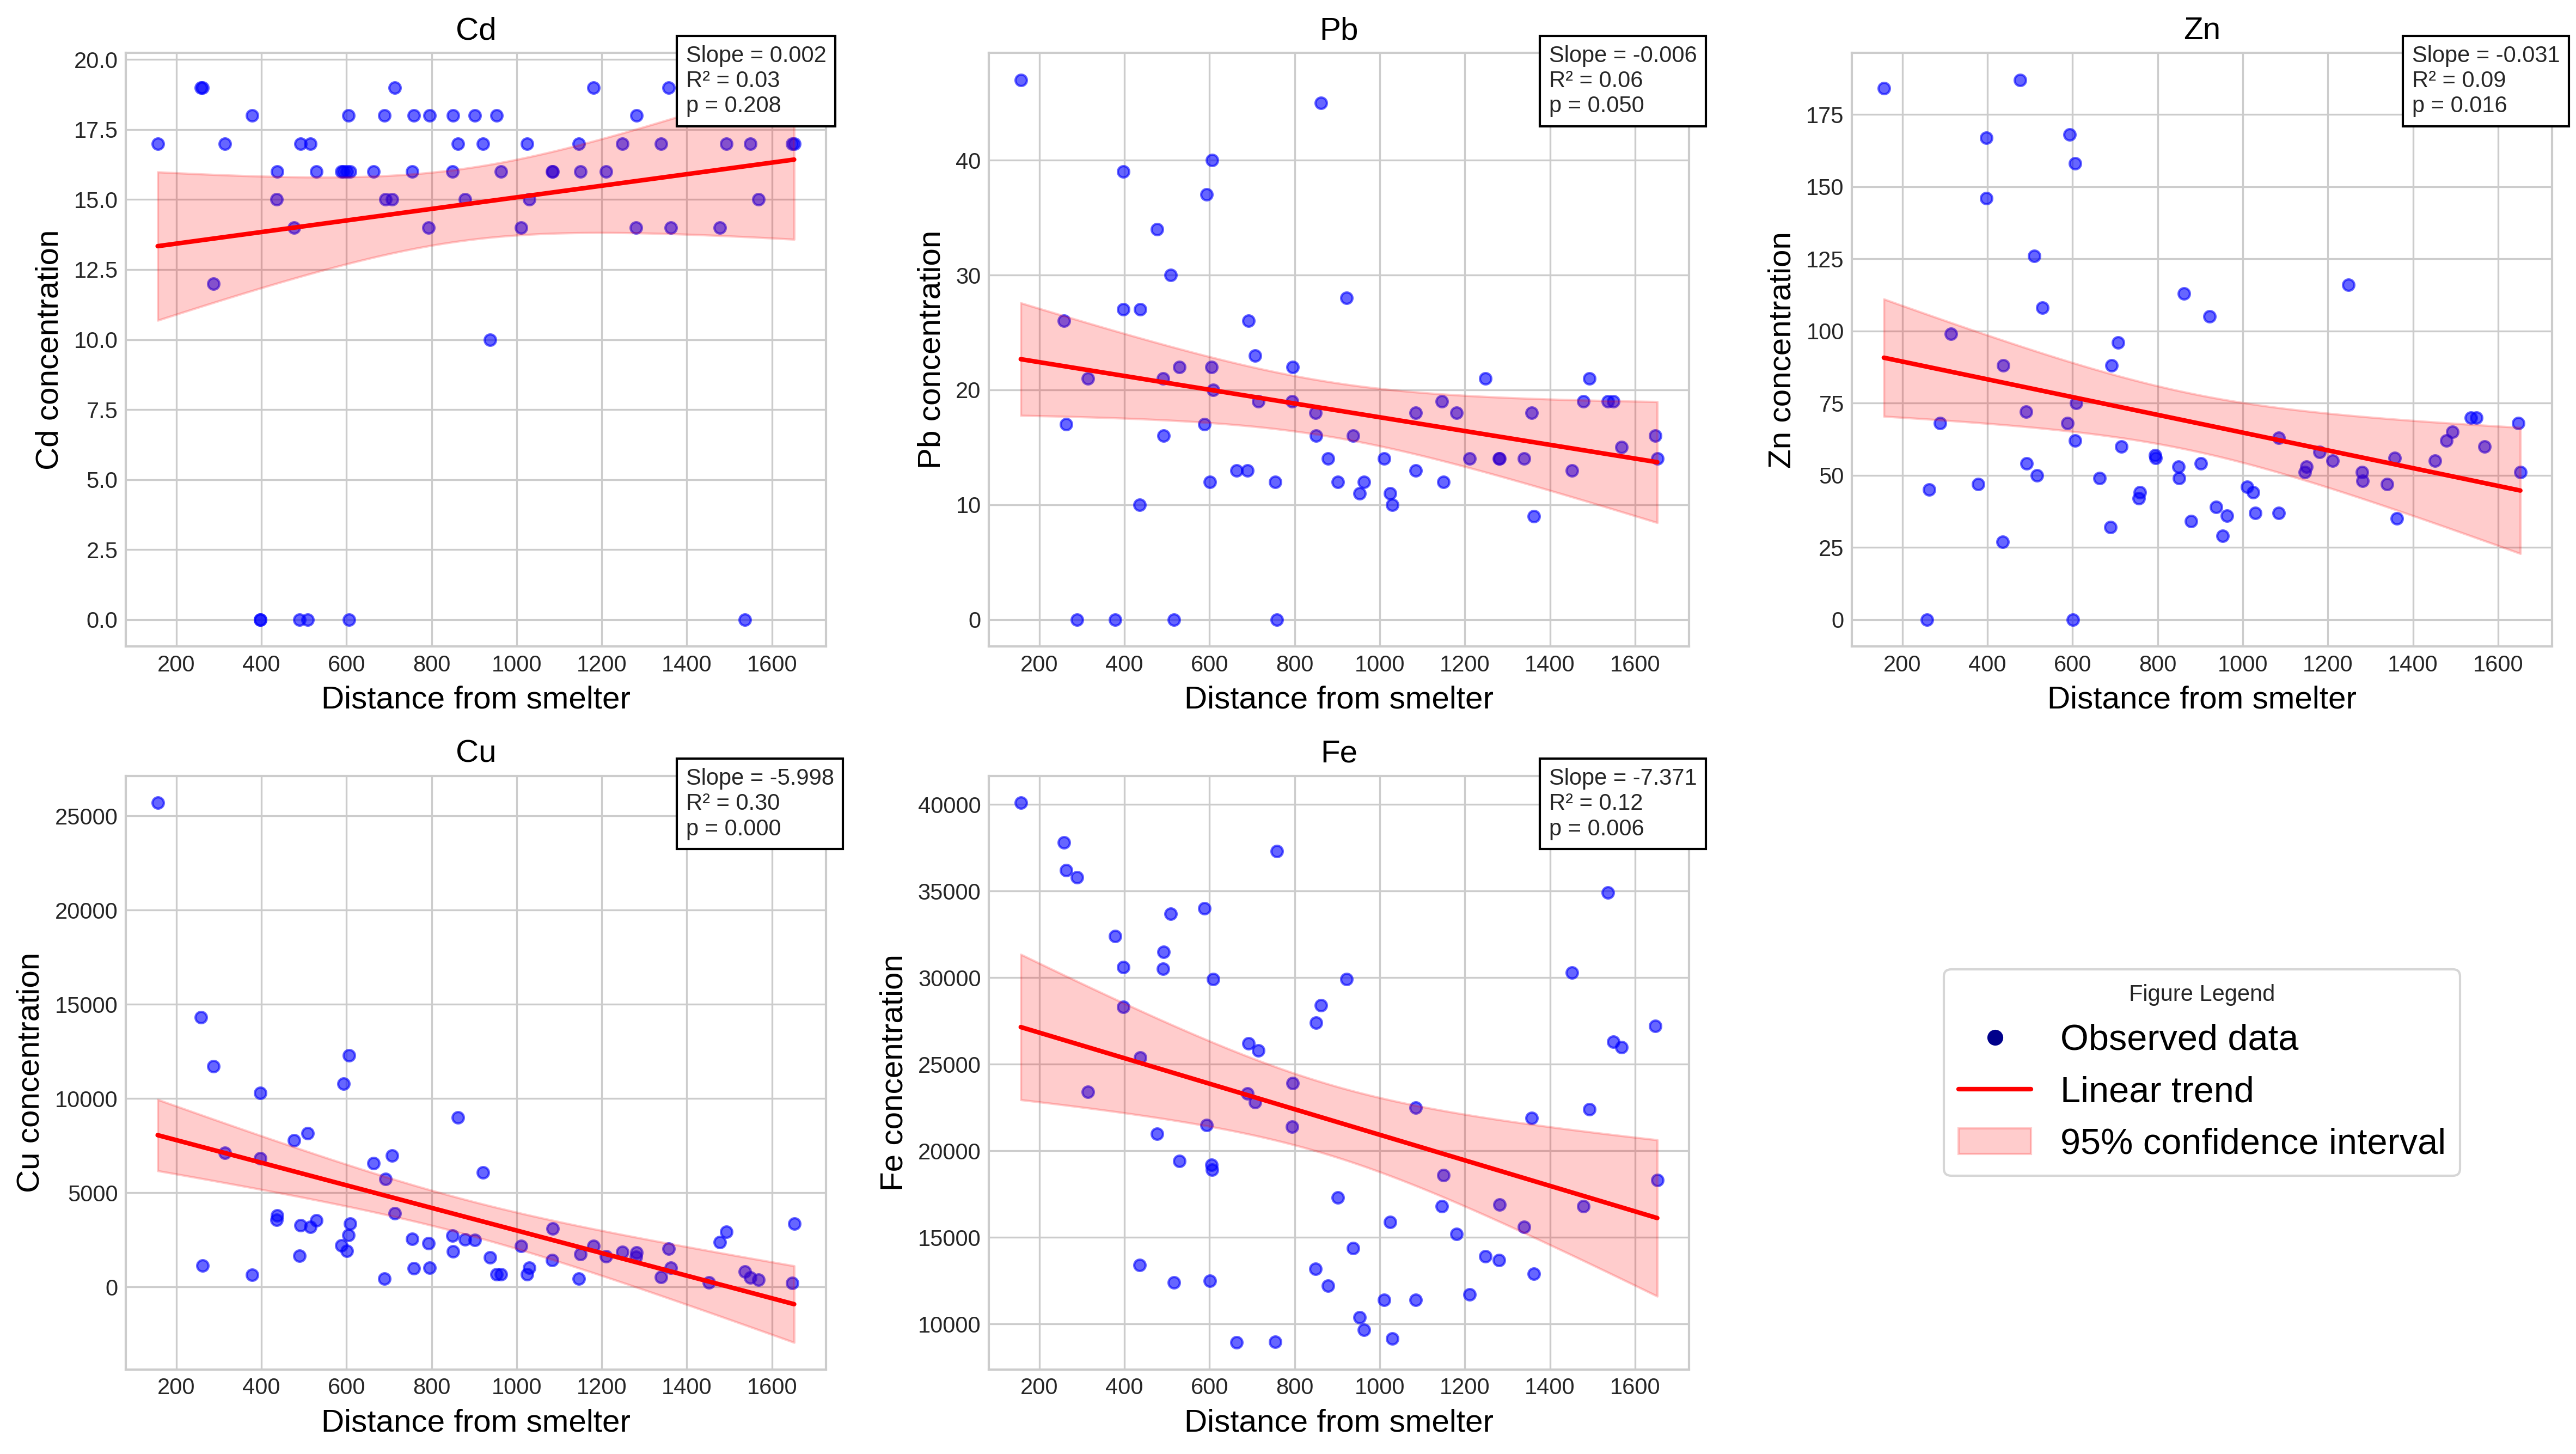

In [6]:
df = Topdf.copy()

metals = ['Cd', 'Pb', 'Zn', 'Cu', 'Fe']

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=300)
axes = axes.flatten()

for i, metal in enumerate(metals):
    ax = axes[i]

    # DATA
    x = df['distance']
    y = df[metal]

    # LINEAR MODEL
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = sm.add_constant(x_pred)

    y_pred = model.predict(X_pred)

    pred = model.get_prediction(X_pred)
    ci = pred.conf_int()

    # PLOTS (NO LEGEND HERE)
    ax.scatter(x, y, color='blue', alpha=0.6, s=25)
    ax.plot(x_pred, y_pred, color='red', linewidth=2)
    ax.fill_between(x_pred, ci[:, 0], ci[:, 1], color='red', alpha=0.2)

    # STATS BOX
    slope = model.params['distance']
    r2 = model.rsquared
    pval = model.pvalues['distance']

    ax.text(
        0.80, 0.90,  ### 0.05, 0.90,
        f"Slope = {slope:.3f}\nR² = {r2:.2f}\np = {pval:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', ), # alpha=0.9
    )

    # labels
    ax.set_title(f'{metal}', fontsize=14, color='black')
    ax.set_xlabel('Distance from smelter', fontsize=14, color='black')
    ax.set_ylabel(f'{metal} concentration', fontsize=14, color='black')

# REMOVE EMPTY SUBPLOT
legend_ax = axes[-1]
fig.delaxes(legend_ax)

# CREATE GLOBAL LEGEND AXIS
legend_ax = fig.add_subplot(2, 3, 6)
legend_ax.axis('off')

# dummy legend handles
scatter_handle = plt.Line2D([0], [0], marker='o', color='w',
                            markerfacecolor='darkblue', markersize=8,
                            label='Observed data')

line_handle = plt.Line2D([0], [0], color='red', linewidth=2,
                         label='Linear trend')

ci_handle = plt.Rectangle((0, 0), 1, 1, color='red', alpha=0.2,
                          label='95% confidence interval')

legend_ax.legend(handles=[scatter_handle, line_handle, ci_handle],
                 loc='center',
                 frameon=True,
                 title="Figure Legend",
                 fontsize=16,
                 labelcolor='black')

# GLOBAL TITLE
###fig.suptitle("Distance–Decay Relationships of Heavy Metals (Linear Regression)", fontsize=14)

plt.tight_layout()
plt.savefig('Distance–Decay Relationships of Heavy Metals (Linear Regression).png', dpi=300, bbox_inches='tight')
plt.savefig('Distance–Decay Relationships of Heavy Metals (Linear Regression).pdf', dpi=300, bbox_inches='tight')
plt.show()

### 2. REGRESSION ANALYSIS OF pH, AND ORGANIC MATTER VARIATION WITH DISTANCE FROM THE EMISSION SOURCE

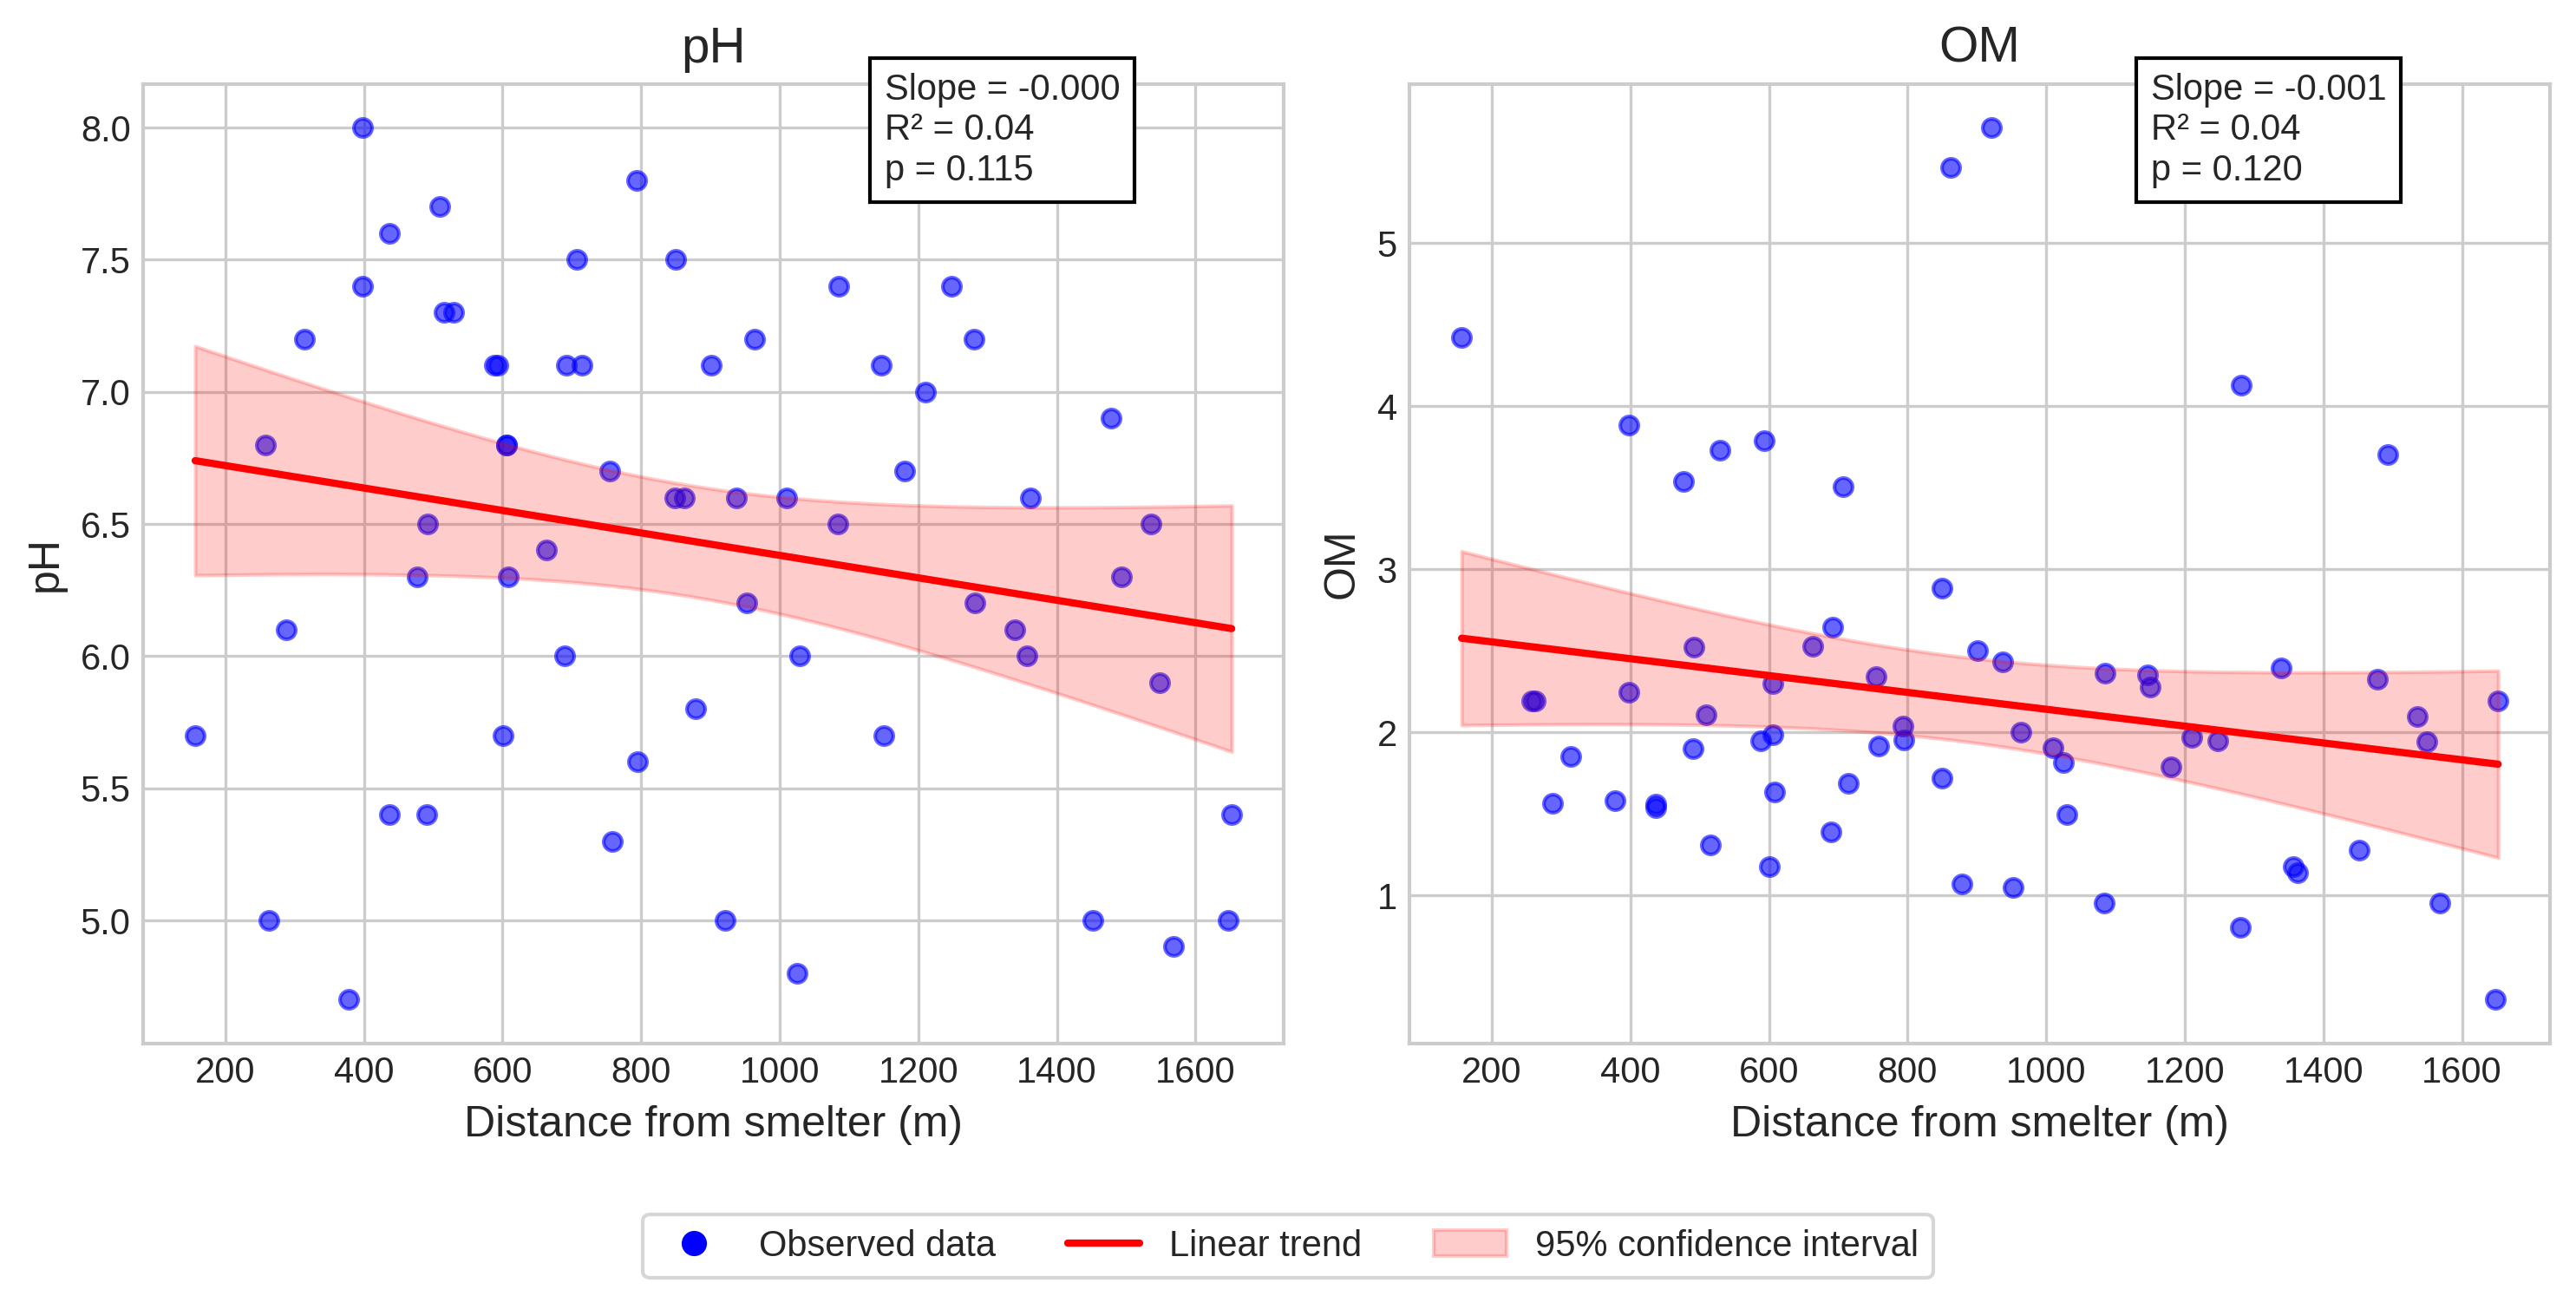

In [8]:
soil = ['pH', 'OM']

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=300)

for i, soil_p in enumerate(soil):

    ax = axes[i]

    # Data
    x = df['distance']
    y = df[soil_p]

    # Linear regression
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    x_pred = np.linspace(x.min(), x.max(), 100)
    X_pred = sm.add_constant(x_pred)

    y_pred = model.predict(X_pred)

    pred = model.get_prediction(X_pred)
    ci = pred.conf_int()

    # Plot
    ax.scatter(x, y, color='blue', alpha=0.6, s=25)
    ax.plot(x_pred, y_pred, color='red', linewidth=2)
    ax.fill_between(
        x_pred,
        ci[:, 0],
        ci[:, 1],
        color='red',
        alpha=0.2
    )

    # Statistics
    slope = model.params['distance']
    r2 = model.rsquared
    pval = model.pvalues['distance']

    ax.text(
        0.65, 0.90,
        f"Slope = {slope:.3f}\nR² = {r2:.2f}\np = {pval:.3f}",
        transform=ax.transAxes,
        bbox=dict(facecolor='white')
    )

    ax.set_title(soil_p, fontsize=14)
    ax.set_xlabel('Distance from smelter (m)', fontsize=12)
    ax.set_ylabel(soil_p, fontsize=12)

# Global legend
scatter_handle = plt.Line2D(
    [0], [0],
    marker='o',
    color='w',
    markerfacecolor='blue',
    markersize=8,
    label='Observed data'
)

line_handle = plt.Line2D(
    [0], [0],
    color='red',
    linewidth=2,
    label='Linear trend'
)

ci_handle = plt.Rectangle(
    (0, 0), 1, 1,
    color='red',
    alpha=0.2,
    label='95% confidence interval'
)

fig.legend(
    handles=[scatter_handle, line_handle, ci_handle],
    loc='lower center',
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig('pH_and_organic_matter_variation_with_distance_Regression.png', dpi=300, bbox_inches='tight')

plt.savefig('pH_and_organic_matter_variation_with_distance_Regression.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
print(f"\n{'='*50}")
print(f"{soil_p}")
print(model.summary())


OM
                            OLS Regression Results                            
Dep. Variable:                     OM   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.493
Date:                Sun, 26 Jul 2026   Prob (F-statistic):              0.120
Time:                        22:06:50   Log-Likelihood:                -90.058
No. Observations:                  63   AIC:                             184.1
Df Residuals:                      61   BIC:                             188.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6573      0.313      8.498     